In [1]:
import os
import random
from collections import defaultdict
 
import numpy as np
import librosa
import matplotlib.pyplot as plt
 
from tqdm import tqdm
 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

In [2]:
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
SEED        = 42
ROOT_PATH   = r"/kaggle/input/cadence-dataset/spectrograms"
BATCH_SIZE  = 16
EPOCHS      = 80
LR          = 1e-3
TEST_SIZE   = 0.2
PATIENCE    = 10       
MIXUP_ALPHA = 0.2
 
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

TRAIN_PATH  = os.path.join(ROOT_PATH, "train")
TEST_PATH   = os.path.join(ROOT_PATH, "test")
GENRES      = sorted(os.listdir(TRAIN_PATH))
NUM_CLASSES = len(GENRES)
LABEL_MAP   = {genre: idx for idx, genre in enumerate(GENRES)}
 
print("Genres:", GENRES, "| Num classes:", NUM_CLASSES)

Genres: ['bhajan', 'deuda', 'lok_dohori', 'newari', 'tamang_selo', 'tharu'] | Num classes: 6


In [3]:
train_files, train_labels = [], []
test_song_chunks = {}      # key: "genre/song_id"  val: {files, label}
 
for genre in GENRES:
    label = LABEL_MAP[genre]
 
    # ── train ─────────────────────────────────────────────────────────────
    train_genre_path = os.path.join(TRAIN_PATH, genre)
    for f in os.listdir(train_genre_path):
        if f.endswith(".npy"):
            train_files.append(os.path.join(train_genre_path, f))
            train_labels.append(label)
 
    # ── test (group chunks by song for voting) ────────────────────────────
    test_genre_path = os.path.join(TEST_PATH, genre)
    song_dict = defaultdict(list)
    for f in os.listdir(test_genre_path):
        if f.endswith(".npy"):
            song_id = f.replace(".npy", "").rsplit("_chunk", 1)[0]
            song_dict[song_id].append(os.path.join(test_genre_path, f))
 
    for song_id, files in song_dict.items():
        test_song_chunks[f"{genre}/{song_id}"] = {
            "files": files,
            "label": label,
        }
 
print(f"\nTrain chunks : {len(train_files)}")
print(f"Test songs   : {len(test_song_chunks)}")

train_files, train_labels = [], []
test_song_chunks = {}      # key: "genre/song_id"  val: {files, label}
 
for genre in GENRES:
    label = LABEL_MAP[genre]
 
    # ── train ─────────────────────────────────────────────────────────────
    train_genre_path = os.path.join(TRAIN_PATH, genre)
    for f in os.listdir(train_genre_path):
        if f.endswith(".npy"):
            train_files.append(os.path.join(train_genre_path, f))
            train_labels.append(label)
 
    # ── test (group chunks by song for voting) ────────────────────────────
    test_genre_path = os.path.join(TEST_PATH, genre)
    song_dict = defaultdict(list)
    for f in os.listdir(test_genre_path):
        if f.endswith(".npy"):
            song_id = f.replace(".npy", "").rsplit("_chunk", 1)[0]
            song_dict[song_id].append(os.path.join(test_genre_path, f))
 
    for song_id, files in song_dict.items():
        test_song_chunks[f"{genre}/{song_id}"] = {
            "files": files,
            "label": label,
        }
 
print(f"\nTrain chunks : {len(train_files)}")
print(f"Test songs   : {len(test_song_chunks)}")


Train chunks : 2903
Test songs   : 53

Train chunks : 2903
Test songs   : 53


In [4]:
def compute_global_stats(file_list, n=500):
    """Estimate mean and std from a random subset of training files."""
    sample = random.sample(file_list, min(n, len(file_list)))
    data   = [np.load(f).ravel() for f in sample]
    flat   = np.concatenate(data)
    return float(flat.mean()), float(flat.std())
 
print("Computing global normalization stats...")
GLOBAL_MEAN, GLOBAL_STD = compute_global_stats(train_files)
print(f"  mean={GLOBAL_MEAN:.4f}  std={GLOBAL_STD:.4f}")

Computing global normalization stats...
  mean=0.4551  std=0.1986


In [5]:
def load_3channel(path):
    mel = np.load(path)                                  # (128, T)
    d1  = librosa.feature.delta(mel, order=1)
    d2  = librosa.feature.delta(mel, order=2)
 
    mel = (mel - GLOBAL_MEAN) / (GLOBAL_STD + 1e-8)
 
    def norm(arr):
        return (arr - arr.mean()) / (arr.std() + 1e-8)
 
    x = np.stack([norm(mel), norm(d1), norm(d2)], axis=0)  # (3, 128, T)
    return x.astype(np.float32)

In [6]:
class NepaliMusicDataset(Dataset):
 
    def __init__(self, files, labels, augment=False):
        self.files   = files
        self.labels  = labels
        self.augment = augment
 
    def __len__(self):
        return len(self.files)
 
    def spec_augment(self, x):
        """SpecAugment scaled to actual clip length."""
        _, T = x.shape
        # two time masks up to 12.5% of clip each
        for _ in range(2):
            t_mask = random.randint(10, max(10, T // 8))
            t0     = random.randint(0, T - t_mask)
            x[:, t0:t0 + t_mask] = 0
        # one frequency mask
        f_mask = random.randint(8, min(30, x.shape[0] // 4))
        f0     = random.randint(0, x.shape[0] - f_mask)
        x[f0:f0 + f_mask, :] = 0
        return x
 
    def __getitem__(self, idx):
        x = load_3channel(self.files[idx])          # (3, 128, T)
 
        if self.augment:
            if random.random() < 0.6:
                x[0] = self.spec_augment(x[0].copy())
            if random.random() < 0.1:               # occasional time flip
                x = x[:, :, ::-1].copy()
 
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y
 
 
train_dataset = NepaliMusicDataset(train_files, train_labels, augment=True)
train_loader  = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
 
x0, _ = train_dataset[0]
print(f"\nChunk shape : {tuple(x0.shape)}")    # (3, 128, 1292)


Chunk shape : (3, 128, 1292)


In [7]:
class MixPool(nn.Module):
    """Concatenated avg+max pooling — no learnable params on the aggregation
    step, which reduces overfitting on small datasets vs learned attention."""
 
    def __init__(self, in_dim):
        super().__init__()
        self.proj = nn.Linear(in_dim * 2, in_dim)
 
    def forward(self, x):
        # x: (B, T, D)
        avg = x.mean(dim=1)
        mx  = x.max(dim=1).values
        return self.proj(torch.cat([avg, mx], dim=-1))
 
 
class EfficientNetBiLSTMClassifier(nn.Module):
 
    def __init__(self, num_classes):
        super().__init__()
 
        # ── EfficientNet-B0 backbone (features only, no avgpool/head) ──────
        backbone      = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.features = backbone.features
 
        # Freeze stem + early stages (stages 0-5); fine-tune stages 6-8
        for param in self.features[:6].parameters():
            param.requires_grad = False
 
        # ── BiLSTM over temporal dimension ───────────────────────────────
        # EfficientNet output for (3, 128, T): (1280, 4, T//32)
        # After mean over freq axis: (1280, T//32)  →  LSTM sees T//32 steps
        # For T=1292: 1292//32 ≈ 41 steps  (was 7 when input was 224×224)
        self.bilstm = nn.LSTM(
            input_size=1280,
            hidden_size=192,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.4,
        )
        self.lstm_drop = nn.Dropout(0.4)
 
        # ── Head ─────────────────────────────────────────────────────────
        self.pool = MixPool(384)          # 192 * 2 bidirectional
        self.classifier = nn.Sequential(
            nn.Linear(384, 128),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )
 
    def forward(self, x):
        # x  : (B, 3, 128, T)
        x = self.features(x)              # (B, 1280, 4, T//32)
        x = x.mean(dim=2)                 # (B, 1280, T//32)  — collapse freq
        x = x.permute(0, 2, 1)           # (B, T//32, 1280)  — LSTM format
        x, _ = self.bilstm(x)            # (B, T//32, 384)
        x = self.lstm_drop(x)
        x = self.pool(x)                  # (B, 384)
        return self.classifier(x)         # (B, num_classes)
 
 
model = EfficientNetBiLSTMClassifier(NUM_CLASSES).to(DEVICE)
total      = sum(p.numel() for p in model.parameters())
trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params     : {total:,}")
print(f"Trainable params : {trainable:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 128MB/s] 



Total params     : 7,504,770
Trainable params : 6,652,962


In [8]:
counts  = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
weights = (1.0 / counts) * counts.sum() / NUM_CLASSES
weights = torch.FloatTensor(weights).to(DEVICE)
 
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
 
print("\nClass weights:")
for g, w in zip(GENRES, weights.cpu().numpy()):
    print(f"  {g:<15} {w:.3f}")


Class weights:
  bhajan          1.172
  deuda           0.916
  lok_dohori      1.021
  newari          1.152
  tamang_selo     0.908
  tharu           0.904


In [9]:
backbone_params = list(model.features[6:].parameters())
custom_params   = (
    list(model.bilstm.parameters())     +
    list(model.lstm_drop.parameters())  +
    list(model.pool.parameters())       +
    list(model.classifier.parameters())
)
 
optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 2e-4},   # fine-tune late backbone gently
    {"params": custom_params,   "lr": LR},     # train custom head faster
], weight_decay=1e-4)
 
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [10]:
def mixup_batch(x, y, alpha=MIXUP_ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0))
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam
 
def mixup_loss(pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)

In [11]:
def train_one_epoch():
    model.train()
    total_loss, correct, total = 0.0, 0, 0
 
    for x, y in tqdm(train_loader, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
 
        if random.random() < 0.5:
            x, ya, yb, lam = mixup_batch(x, y)
            out  = model(x)
            loss = mixup_loss(out, ya, yb, lam)
            preds = out.argmax(dim=1)
            correct += (
                lam * (preds == ya).float() +
                (1 - lam) * (preds == yb).float()
            ).sum().item()
        else:
            out   = model(x)
            loss  = criterion(out, y)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
 
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
 
        total_loss += loss.item()
        total      += y.size(0)
 
    return total_loss / len(train_loader), correct / total

In [12]:
def evaluate_model():
    model.eval()
 
    song_correct, song_total     = 0, 0
    chunk_correct, chunk_total   = 0, 0
    all_song_preds,  all_song_targets  = [], []
    all_chunk_preds, all_chunk_targets = [], []
 
    with torch.no_grad():
        for song_key, info in tqdm(test_song_chunks.items(), leave=False):
            label        = info["label"]
            chunk_logits = []
 
            for fp in info["files"]:
                x = load_3channel(fp)
                x = torch.tensor(x).unsqueeze(0).to(DEVICE)
                logits = model(x)                          # (1, num_classes)
 
                # chunk-level
                chunk_pred = logits.argmax(dim=1).item()
                chunk_correct += int(chunk_pred == label)
                chunk_total   += 1
                all_chunk_preds.append(chunk_pred)
                all_chunk_targets.append(label)
 
                chunk_logits.append(logits)
 
            # song-level (soft voting)
            avg_logits = torch.stack(chunk_logits).mean(dim=0)
            song_pred  = avg_logits.argmax(dim=1).item()
            song_correct += int(song_pred == label)
            song_total   += 1
            all_song_preds.append(song_pred)
            all_song_targets.append(label)
 
    song_acc  = song_correct  / song_total
    chunk_acc = chunk_correct / chunk_total
 
    return (
        song_acc,  chunk_acc,
        all_song_preds,  all_song_targets,
        all_chunk_preds, all_chunk_targets,
    )

In [13]:
best_acc    = 0.0
patience_ct = 0
history     = {
    "train_loss": [], "train_acc": [],
    "song_acc":   [], "chunk_acc": [],
}
 
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
 
    tr_loss, tr_acc = train_one_epoch()
 
    song_acc, chunk_acc, \
    s_preds, s_targets, \
    c_preds, c_targets = evaluate_model()
 
    scheduler.step()
 
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["song_acc"].append(song_acc)
    history["chunk_acc"].append(chunk_acc)
 
    print(f"  train  loss={tr_loss:.4f}  acc={tr_acc:.4f}")
    print(f"  test   chunk={chunk_acc:.4f}  song={song_acc:.4f}")
     
    if chunk_acc > best_acc:
        best_acc    = chunk_acc
        patience_ct = 0
        torch.save(model.state_dict(), "best_genre_model.pth")
        print(f"  ✓ saved  (chunk={best_acc:.4f})")
    else:
        patience_ct += 1
 
    if patience_ct >= PATIENCE:
        print("\nEarly stopping.")
        break


Epoch 1/80


  train  loss=1.3770  acc=0.4907
  test   chunk=0.6568  song=0.7358
  ✓ saved  (chunk=0.6568)

Epoch 2/80


  train  loss=1.0382  acc=0.7408
  test   chunk=0.6840  song=0.7170
  ✓ saved  (chunk=0.6840)

Epoch 3/80


  train  loss=0.8463  acc=0.8228
  test   chunk=0.7395  song=0.8113
  ✓ saved  (chunk=0.7395)

Epoch 4/80


  train  loss=0.8137  acc=0.8511
  test   chunk=0.7136  song=0.7736

Epoch 5/80


...

  train  loss=0.6111  acc=0.9423
  test   chunk=0.7568  song=0.7925

Epoch 41/80


  train  loss=0.5680  acc=0.9576
  test   chunk=0.7309  song=0.7925

Epoch 42/80


  train  loss=0.5721  acc=0.9527
  test   chunk=0.7679  song=0.7925

Epoch 43/80


  train  loss=0.5813  acc=0.9484
  test   chunk=0.7728  song=0.8302

Epoch 44/80


  train  loss=0.5603  acc=0.9593
  test   chunk=0.7654  song=0.8113

Early stopping.



Best song-level  accuracy : 0.8679
Best chunk-level accuracy : 0.7852

── Song-level classification report ──
              precision    recall  f1-score   support

      bhajan       1.00      0.78      0.88         9
       deuda       0.86      0.75      0.80         8
  lok_dohori       0.80      1.00      0.89         8
      newari       0.71      1.00      0.83        10
 tamang_selo       1.00      0.80      0.89        10
       tharu       1.00      0.88      0.93         8

    accuracy                           0.87        53
   macro avg       0.90      0.87      0.87        53
weighted avg       0.89      0.87      0.87        53


── Chunk-level classification report ──
              precision    recall  f1-score   support

      bhajan       0.95      0.88      0.91       166
       deuda       0.80      0.54      0.64       141
  lok_dohori       0.66      0.94      0.77       124
      newari       0.62      0.79      0.69       115
 tamang_selo       0.87      0.86 

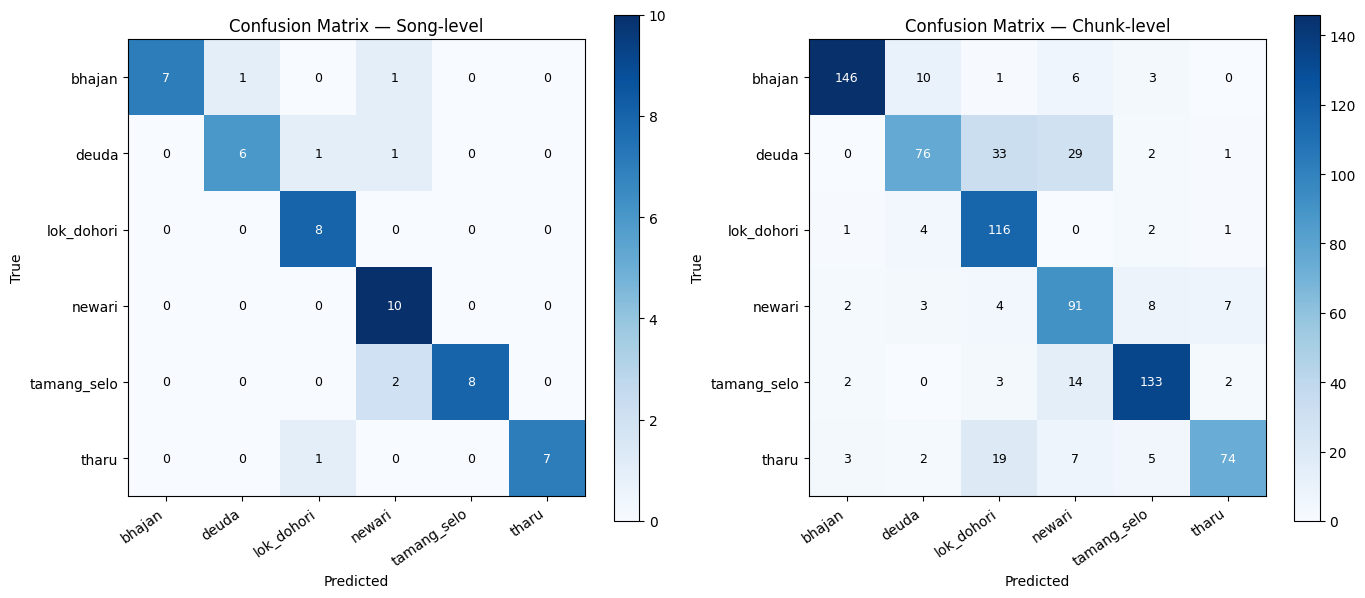

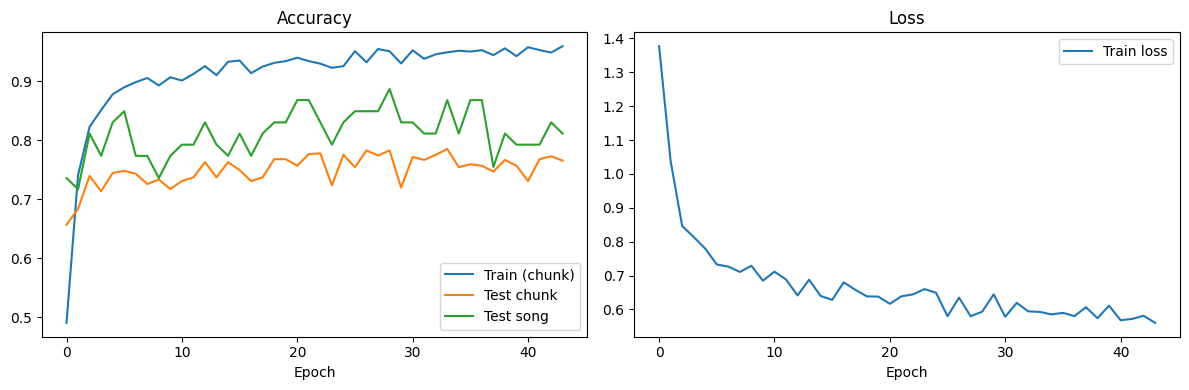

In [14]:
model.load_state_dict(torch.load("best_genre_model.pth"))
 
song_acc, chunk_acc, \
s_preds, s_targets, \
c_preds, c_targets = evaluate_model()
 
print(f"\nBest song-level  accuracy : {song_acc:.4f}")
print(f"Best chunk-level accuracy : {chunk_acc:.4f}")
 
print("\n── Song-level classification report ──")
print(classification_report(s_targets, s_preds, target_names=GENRES))
 
print("\n── Chunk-level classification report ──")
print(classification_report(c_targets, c_preds, target_names=GENRES))
 
# =============================================================================
# PLOTS
# =============================================================================
 
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
for ax, preds, tgts, title in [
    (axes[0], s_preds, s_targets, "Song-level"),
    (axes[1], c_preds, c_targets, "Chunk-level"),
]:
    cm = confusion_matrix(tgts, preds)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(GENRES, rotation=35, ha="right")
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_yticklabels(GENRES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — {title}")
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() * 0.5 else "black",
                    fontsize=9)
    plt.colorbar(im, ax=ax)
 
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()
 
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].plot(history["train_acc"],  label="Train (chunk)")
axes[0].plot(history["chunk_acc"],  label="Test chunk")
axes[0].plot(history["song_acc"],   label="Test song")
axes[0].set_title("Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epoch")
 
axes[1].plot(history["train_loss"], label="Train loss")
axes[1].set_title("Loss")
axes[1].legend()
axes[1].set_xlabel("Epoch")
 
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()